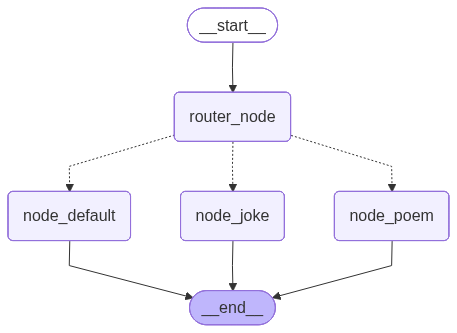

2026-07-09 10:17:02.171 | INFO     | __main__:router_node:41 - 路由节点已经执行
2026-07-09 10:17:03.045 | INFO     | __main__:router_node:49 - 路由结果为:{'topic': '荷花', 'mode': 'poem'}
2026-07-09 10:17:03.046 | INFO     | __main__:router:54 - 路由函数已经执行
2026-07-09 10:17:03.047 | INFO     | __main__:router:56 - 路由至 node_poem 节点
2026-07-09 10:17:03.048 | INFO     | __main__:node_poem:66 - node_poem已执行


{'username': '小王', 'user_input': '写一首关于荷花的诗', 'output': AIMessage(content='《咏荷》\n翠盖摇风香满塘，红蕖照水影成双。\n玉露凝珠倾碧盘，淤泥不染自清芳。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 22, 'total_tokens': 58, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 22}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'e731204d-e700-4f2c-972d-0be78cb614e2', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f44aa-0d49-7100-9f3b-8fecf47c2489-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 36, 'total_tokens': 58, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})}


In [1]:
from typing import TypedDict, Annotated, Literal

from dotenv import  load_dotenv
from jupyter_builder.jupyterlab_semver import BUILD
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph import graph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph,START,END
from loguru import logger
from pikepdf._core import Annotation

load_dotenv(override=True)

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body={
        "thinking":{
            "type":"disabled"
        }
    }
)

#1. 声明状态
#1.1 全局状态
class OverAllState(TypedDict):
    username:str
    user_input:str
    output:str

#1.2 私有状态
class StructuredOutputState(TypedDict):
    topic:Annotated[str,"主题"]
    mode:Annotated[Literal["poem","joke"],"模式"]

model_with_structure = model.with_structured_output(schema=StructuredOutputState)


#2. 声明节点
def router_node(state:OverAllState) -> StructuredOutputState:
    logger.info("路由节点已经执行")
    user_input = state["user_input"]
    res = model_with_structure.invoke(
        [
            HumanMessage(user_input)
        ]
    )

    logger.info("路由结果为:{}",res)

    return res

def router(state:StructuredOutputState) -> Literal["node_poem","node_joke","node_default"]:
    logger.info("路由函数已经执行")
    if state["mode"] == "poem":
        logger.info("路由至 node_poem 节点")
        return "node_poem"
    elif state["mode"] == "joke":
        logger.info("路由至 node_joke 节点")
        return "node_joke"
    logger.info("路由到兜底的节点")
    return "node_default"

# 2.1 写诗节点
def node_poem(state:StructuredOutputState) -> OverAllState:
    logger.info(f"node_poem已执行")
    topic = state["topic"]
    poem = model.invoke(
        [
            HumanMessage(f"写一首关于{topic}主题的七言绝句,不要赏析,只写诗句的部分").content
        ]
    )
    return {
        "output":poem
    }

# 2.2 写笑话节点
def node_joke(state:StructuredOutputState) -> OverAllState:
    logger.info(f"node_joke已执行")
    topic = state["topic"]
    joke = model.invoke(
        [
            HumanMessage(f"写一首关于{topic}主题的笑话,字数在100以内").content
        ]
    )
    return {
        "output":joke
    }

#2.3 兜底节点
def node_default(state:StructuredOutputState) -> OverAllState:
    logger.info(f"node_default已经执行")
    return {
        "output":"无法处理的任务类型"
    }


#3. 构件图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("router_node",router_node)
builder.add_node("node_poem",node_poem)
builder.add_node("node_joke",node_joke)
builder.add_node("node_default",node_default)

builder.add_edge(START,"router_node")
builder.add_conditional_edges("router_node",router,path_map = ["node_poem","node_joke","node_default"])
builder.add_edge("node_poem",END)
builder.add_edge("node_joke",END)
builder.add_edge("node_default",END)

#4. 添加内存的检查点
checkpointer = InMemorySaver()
config = {"configurable":{"thread_id":"123"}}
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

res = graph.invoke({
    "username":"小王",
    "user_input":"写一首关于荷花的诗"
},config=config)
print(res)


In [2]:
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)

[StateSnapshot(values={'username': '小王', 'user_input': '写一首关于荷花的诗', 'output': AIMessage(content='《咏荷》\n翠盖摇风香满塘，红蕖照水影成双。\n玉露凝珠倾碧盘，淤泥不染自清芳。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 22, 'total_tokens': 58, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 22}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'e731204d-e700-4f2c-972d-0be78cb614e2', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f44aa-0d49-7100-9f3b-8fecf47c2489-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 36, 'total_tokens': 58, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), 'topic': '荷花', 'mode': 'poem'}, next=(), config={'configurable': {'thread_id': '123', 'chec

In [3]:
# 1. 获取某一个节点的位置
before_router_checkpoint = next(h for h in history_checkpoints if h.next == ('router_node',))
print(before_router_checkpoint)

StateSnapshot(values={'username': '小王', 'user_input': '写一首关于荷花的诗'}, next=('router_node',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17b3c4-5a24-63bb-8000-85d9b9e18aaa'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-09T02:17:02.171221+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17b3c4-5a20-6f00-bfff-9557d5edce32'}}, tasks=(PregelTask(id='924200b3-6d23-1263-5de6-c7e5e9f30e60', name='router_node', path=('__pregel_pull', 'router_node'), error=None, interrupts=(), state=None, result={'topic': '荷花', 'mode': 'poem'}),), interrupts=())


In [5]:
change_input = graph.update_state(
    config=before_router_checkpoint.config,
    values={"user_input":"帮我写一个荷花的笑话"},
    as_node=START
)
print(change_input)
graph.get_state(change_input)

{'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17b403-e9fe-6392-8001-60e9b40bcc97'}}


StateSnapshot(values={'username': '小王', 'user_input': '帮我写一个荷花的笑话'}, next=('router_node',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17b403-e9fe-6392-8001-60e9b40bcc97'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-09T02:45:28.398515+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17b3c4-5a24-63bb-8000-85d9b9e18aaa'}}, tasks=(PregelTask(id='4017d9ac-0abf-894a-3553-1a14546e0ed8', name='router_node', path=('__pregel_pull', 'router_node'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [6]:
res = graph.invoke(None,config=change_input)
print(res)

2026-07-09 10:46:11.144 | INFO     | __main__:router_node:41 - 路由节点已经执行
2026-07-09 10:46:11.967 | INFO     | __main__:router_node:49 - 路由结果为:{'topic': '荷花', 'mode': 'joke'}
2026-07-09 10:46:11.968 | INFO     | __main__:router:54 - 路由函数已经执行
2026-07-09 10:46:11.969 | INFO     | __main__:router:59 - 路由至 node_joke 节点
2026-07-09 10:46:11.970 | INFO     | __main__:node_joke:79 - node_joke已执行


{'username': '小王', 'user_input': '帮我写一个荷花的笑话', 'output': AIMessage(content='# 荷花笑话\n\n一个小和尚问师父：“师父，为什么荷花出淤泥而不染？”\n\n师父答：“因为它有自洁功能。”\n\n小和尚又问：“那为什么我们每天都要洗澡？”\n\n师父：“因为我们没有荷叶表面的纳米结构。”\n\n小和尚恍然大悟：“原来荷花是自带科技树啊！”', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 16, 'total_tokens': 76, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 16}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '3fc88928-ac96-42f3-b157-fe3a6c7978cc', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f44c4-bd02-74b1-9714-b00b465fa8b0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 60, 'total_tokens': 76, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})}


In [9]:
# update_state调用的时候,基于as_node实现 先执行路由逻辑在完成values的赋值 => 没法正确实现路由的
skip_router_config = graph.update_state(
    config=before_router_checkpoint.config,
    values={"topic":"狸花猫","mode":"笑话"},
    as_node="router_node"
)

print(skip_router_config)

graph.get_state(skip_router_config)

2026-07-09 10:49:47.414 | INFO     | __main__:router:54 - 路由函数已经执行
2026-07-09 10:49:47.414 | INFO     | __main__:router:61 - 路由到兜底的节点


{'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17b40d-902c-6757-8001-a35e2424468c'}}


StateSnapshot(values={'username': '小王', 'user_input': '写一首关于荷花的诗', 'topic': '狸花猫', 'mode': '笑话'}, next=('node_default',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17b40d-902c-6757-8001-a35e2424468c'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-09T02:49:47.415726+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17b3c4-5a24-63bb-8000-85d9b9e18aaa'}}, tasks=(PregelTask(id='cc41eaf6-f4ca-3726-395b-f453802349ff', name='node_default', path=('__pregel_pull', 'node_default'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [10]:
graph.invoke(None,config=skip_router_config)

2026-07-09 10:51:44.781 | INFO     | __main__:node_default:92 - node_default已经执行


{'username': '小王', 'user_input': '写一首关于荷花的诗', 'output': '无法处理的任务类型'}